In [1]:
import pyomo.environ as pyo
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Data import

In [2]:
gen = pd.read_csv("data/generators.csv")
ld = pd.read_csv("data/load.csv")
dem = pd.read_csv("data/demand.csv")
win = pd.read_csv("data/wind.csv")
win

,Unit#,Node,P_{i}^{max},C_{i},Capacity_factor,City
0,NaN,NaN,(MW),($/MWh),(-),(-)
1,1.0,3.0,200,0,0.755573615,Glasgow
2,2.0,5.0,200,0,0.83997045,Perth
3,3.0,7.0,200,0,0.979492705,Aberdeen
4,4.0,16.0,200,0,0.700360245,Liverpool
5,5.0,21.0,200,0,0.42922841,Birmingham
6,6.0,23.0,200,0,0.83997045,Perth2


In [3]:
generators = gen.loc[1:,["Node", "P_{i}^{max}","C_{i}"]].copy()
generators.rename(
    columns = {
        "Node": "node",
        "P_{i}^{max}": "max_power_out", 
        "C_{i}": "offer_price",
    },
    inplace=True
)

In [4]:
generators["max_power_out"] = pd.to_numeric(generators["max_power_out"])
generators["offer_price"] = pd.to_numeric(generators["offer_price"])
generators["node"] = generators["node"].astype(int)
generators

,node,max_power_out,offer_price
1,1,152,13.32
2,2,152,13.32
3,7,350,20.70
4,13,591,20.93
5,15,60,26.11
6,15,155,10.52
7,16,155,10.52
8,18,400,6.02
9,21,400,5.47
10,22,300,0.00


In [5]:
load = ld.loc[1:,["Systemdemand"]].copy()
load.rename(columns = {"Systemdemand": "total_demand_MW"}, inplace = True)
load["total_demand_MW"] = pd.to_numeric(load["total_demand_MW"])
load

,total_demand_MW
1,1775.835
2,1669.815
3,1590.300
4,1563.795
5,1563.795
6,1590.300
7,1961.370
8,2279.430
9,2517.975
10,2544.480


In [6]:
demand_bid_price = pd.read_csv("data/demand_bid_price.csv")
demand_bid_price.index = demand_bid_price.index + 1
demand_bid_price

,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
1,101.127217,106.811330,80.521952,116.133558,112.082232,103.234994,116.396888,108.398170,84.555193,92.208018,...,95.844651,84.317539,105.642524,108.705301,115.505180,97.604084,83.144928,106.073313,85.850302,80.131614
2,118.426237,118.020336,88.419296,81.470308,85.957972,114.169540,90.991458,88.264519,102.204776,90.253734,...,93.747683,81.672699,80.381189,116.795337,113.885372,89.094689,118.536220,84.129065,95.763814,92.599214
3,118.062623,105.576950,110.710009,84.019933,82.682673,88.658781,108.298951,100.025745,119.182889,102.788608,...,106.133342,100.341509,109.855485,101.004841,100.484263,95.877056,110.067779,117.860222,110.676602,96.372366
4,89.874924,94.681936,119.044133,113.145978,84.752128,101.792806,118.511140,80.366759,110.896102,114.505154,...,88.196008,88.771056,81.926739,111.868347,94.733491,118.811447,97.227594,87.984566,109.196666,86.189842
5,105.377104,102.377284,83.643760,114.670330,119.385501,83.976561,102.081671,108.639910,103.502892,91.916747,...,86.158701,80.328431,97.784537,119.541351,97.064308,87.065209,80.178380,103.962318,95.821335,83.828402
6,93.919847,113.581839,114.828394,91.924509,107.735758,80.996899,84.364037,80.524787,115.715961,112.133027,...,81.196711,107.192777,97.349360,88.470737,94.967568,81.418875,104.580175,104.801599,83.875902,113.672393
7,109.846102,101.436452,106.781515,118.675232,118.450341,93.999835,107.153233,86.213196,99.346242,94.697992,...,81.760983,91.664125,119.054220,80.559043,91.192436,115.392704,116.133444,107.465188,104.352166,82.274081
8,109.690298,106.749758,93.800255,114.014274,91.576800,115.756787,116.259716,100.180730,82.872122,92.223956,...,107.392946,109.445206,103.490083,90.606647,104.201036,85.452427,117.612604,100.369246,103.128644,110.363573
9,89.736232,86.084745,118.044601,112.014570,112.084353,116.987064,87.225628,101.012072,107.084044,110.471717,...,92.245972,87.833055,99.325599,89.661655,104.274501,95.090592,103.127863,81.745824,95.644950,80.780402
10,107.601800,90.892620,80.319177,104.945243,81.362403,98.620520,92.559839,91.926153,107.420196,92.807440,...,86.948945,103.653475,114.227432,92.464863,117.735732,83.058994,109.495349,88.418162,112.912204,119.256812


In [7]:
demand = dem.loc[1:, ["Node", "%ofsystemload"]].copy()
demand.rename(
    columns = {
        "Node": "node",
        "%ofsystemload": "system_load_%"
    },
    inplace=True
)
demand["node"] = demand["node"].astype(int)
demand["system_load_%"] = pd.to_numeric(demand["system_load_%"])
demand["bid_price"] = demand_bid_price["1"]
demand

,node,system_load_%,bid_price
1,1,3.8,101.127217
2,2,3.4,118.426237
3,3,6.3,118.062623
4,4,2.6,89.874924
5,5,2.5,105.377104
6,6,4.8,93.919847
7,7,4.4,109.846102
8,8,6.0,109.690298
9,9,6.1,89.736232
10,10,6.8,107.601800


In [8]:
wind = win.loc[1:,["Node", "P_{i}^{max}", "C_{i}", "Capacity_factor"]].copy()
wind.rename(
    columns = {
        "Node": "node",
        "P_{i}^{max}": "max_power_out",
        "C_{i}": "offer_price",
        "Capacity_factor": "capacity_factor"
    },
    inplace=True
)
wind["node"] = wind["node"].astype(int)
for c in ['max_power_out', 'offer_price', 'capacity_factor']:
    wind[c] = pd.to_numeric(wind[c])
wind

,node,max_power_out,offer_price,capacity_factor
1,3,200,0,0.755574
2,5,200,0,0.839970
3,7,200,0,0.979493
4,16,200,0,0.700360
5,21,200,0,0.429228
6,23,200,0,0.839970


In [9]:
hourly_demand = pd.DataFrame(index=demand.index)
for i in load.index:
    hourly_demand[i] = demand["system_load_%"]/100*load.loc[i,"total_demand_MW"]

hourly_demand.loc["total_check"] = hourly_demand.sum(axis=0)
hourly_demand.loc["total_demand_MW"] = load["total_demand_MW"].values
hourly_demand

,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
1,67.481730,63.452970,60.4314,59.424210,59.424210,60.4314,74.53206,86.61834,95.683050,96.69024,...,93.668670,93.668670,99.711810,100.7190,100.7190,96.69024,91.654290,83.596770,73.524870,63.452970
2,60.378390,56.773710,54.0702,53.169030,53.169030,54.0702,66.68658,77.50062,85.611150,86.51232,...,83.808810,83.808810,89.215830,90.1170,90.1170,86.51232,82.006470,74.797110,65.785410,56.773710
3,111.877605,105.198345,100.1889,98.519085,98.519085,100.1889,123.56631,143.60409,158.632425,160.30224,...,155.292795,155.292795,165.311685,166.9815,166.9815,160.30224,151.953165,138.594645,121.896495,105.198345
4,46.171710,43.415190,41.3478,40.658670,40.658670,41.3478,50.99562,59.26518,65.467350,66.15648,...,64.089090,64.089090,68.223870,68.9130,68.9130,66.15648,62.710830,57.197790,50.306490,43.415190
5,44.395875,41.745375,39.7575,39.094875,39.094875,39.7575,49.03425,56.98575,62.949375,63.61200,...,61.624125,61.624125,65.599875,66.2625,66.2625,63.61200,60.298875,54.997875,48.371625,41.745375
6,85.240080,80.151120,76.3344,75.062160,75.062160,76.3344,94.14576,109.41264,120.862800,122.13504,...,118.318320,118.318320,125.951760,127.2240,127.2240,122.13504,115.773840,105.595920,92.873520,80.151120
7,78.136740,73.471860,69.9732,68.806980,68.806980,69.9732,86.30028,100.29492,110.790900,111.95712,...,108.458460,108.458460,115.455780,116.6220,116.6220,111.95712,106.126020,96.796260,85.134060,73.471860
8,106.550100,100.188900,95.4180,93.827700,93.827700,95.4180,117.68220,136.76580,151.078500,152.66880,...,147.897900,147.897900,157.439700,159.0300,159.0300,152.66880,144.717300,131.994900,116.091900,100.188900
9,108.325935,101.858715,97.0083,95.391495,95.391495,97.0083,119.64357,139.04523,153.596475,155.21328,...,150.362865,150.362865,160.063695,161.6805,161.6805,155.21328,147.129255,134.194815,118.026765,101.858715
10,120.756780,113.547420,108.1404,106.338060,106.338060,108.1404,133.37316,155.00124,171.222300,173.02464,...,167.617620,167.617620,178.431660,180.2340,180.2340,173.02464,164.012940,149.594220,131.570820,113.547420


In [10]:
hourly_demand.loc[2,1]

np.float64(60.37839)

# Model setup

In [11]:
model = pyo.ConcreteModel()

# Define sets
model.GenSet = pyo.Set(initialize = generators.index)
model.DemSet = pyo.Set(initialize = demand.index)
model.WinSet = pyo.Set(initialize = wind.index)

# Define variables
model.Pgen = pyo.Var(model.GenSet, within = pyo.NonNegativeReals)
model.Pdem = pyo.Var(model.DemSet, within = pyo.NonNegativeReals)
model.Pwin = pyo.Var(model.WinSet, within = pyo.NonNegativeReals)

# Define objective
def objective_function(model):
    utility = 0
    for i in model.DemSet:
        utility = utility + (model.Pdem[i] * demand.loc[i,"bid_price"])

    cost = 0
    for i in model.GenSet:
        cost = cost + (model.Pgen[i] * generators.loc[i,"offer_price"])
    for i in model.WinSet:
        cost = cost + (model.Pwin[i] * wind.loc[i, "offer_price"])

    return utility-cost

model.objective = pyo.Objective(rule = objective_function, sense = pyo.maximize)

# Define generation max objective 
def generator_max_out_constraint(model, g):
    return model.Pgen[g] <= generators.loc[g, "max_power_out"]
model.Pgenmax = pyo.Constraint(model.GenSet, rule = generator_max_out_constraint)

# Define wind max objective
def wind_max_out_constraint(model, w):
    return model.Pwin[w] <= wind.loc[w, "max_power_out"] * wind.loc[w, "capacity_factor"]
model.Pwinmax = pyo.Constraint(model.WinSet, rule = wind_max_out_constraint)

# Define demand max objective
def demand_max_power(model, d):
    return model.Pdem[d] <= hourly_demand.loc[d,1]
model.Pdemmax = pyo.Constraint(model.DemSet, rule = demand_max_power)

# Define power balance constraint
def power_balance(model):
    pdemand = sum(model.Pdem[d] for d in model.DemSet)
    psupply = sum(model.Pgen[g] for g in model.GenSet) + sum(model.Pwin[w] for w in model.WinSet)
    return pdemand == psupply
model.Pbalance = pyo.Constraint(rule = power_balance)

In [12]:
# Solve model
model.dual = pyo.Suffix(direction = pyo.Suffix.IMPORT)
solver = pyo.SolverFactory("highs")

results = solver.solve(model)
results

{'Problem': [{'Lower bound': 175455.21826624672, 'Upper bound': 175455.21826624672, 'Number of objectives': 1, 'Number of constraints': nan, 'Number of variables': nan, 'Sense': 'maximize'}], 'Solver': [{'Status': 'ok', 'Termination condition': 'optimal', 'Termination message': 'TerminationCondition.convergenceCriteriaSatisfied'}]}

In [13]:
market_price = model.dual[model.Pbalance]
print(market_price)

6.02


In [14]:
type(model.GenSet)

pyomo.core.base.set.OrderedScalarSet

# Extract results

In [15]:
generators_results = pd.DataFrame()
generators_results.index = model.GenSet
generators_results["Pgen"] = [pyo.value(model.Pgen[g]) for g in model.GenSet]
generators_results["offer_price"] = generators["offer_price"]
generators_results["revenue"] = generators_results["Pgen"] * market_price
generators_results["profit"] = generators_results["revenue"] - generators_results["Pgen"] * generators["offer_price"]
generators_results

,Pgen,offer_price,revenue,profit
1,0.000000,13.32,0.000000,0.0
2,0.000000,13.32,0.000000,0.0
3,0.000000,20.70,0.000000,0.0
4,0.000000,20.93,0.000000,0.0
5,0.000000,26.11,0.000000,0.0
6,0.000000,10.52,0.000000,0.0
7,0.000000,10.52,0.000000,0.0
8,166.915825,6.02,1004.833266,0.0
9,400.000000,5.47,2408.000000,220.0
10,300.000000,0.00,1806.000000,1806.0


In [16]:
wind_results = pd.DataFrame()
wind_results.index = model.WinSet
wind_results["Pwin"] = [pyo.value(model.Pwin[w]) for w in model.WinSet] 
wind_results["offer_price"] = wind["offer_price"]
wind_results["revenue"] = wind_results["Pwin"] * market_price
wind_results["profit"] = wind_results["revenue"] - wind_results["Pwin"] * wind["offer_price"]
wind_results

,Pwin,offer_price,revenue,profit
1,151.114723,0,909.710632,909.710632
2,167.994090,0,1011.324422,1011.324422
3,195.898541,0,1179.309217,1179.309217
4,140.072049,0,843.233735,843.233735
5,85.845682,0,516.791006,516.791006
6,167.994090,0,1011.324422,1011.324422


In [17]:
demand_results = pd.DataFrame()
demand_results.index = model.DemSet
demand_results["Pdem"] = [pyo.value(model.Pdem[d]) for d in model.DemSet]
demand_results["bid_price"] = demand["bid_price"]
demand_results["total_cost"] = demand_results["Pdem"] * market_price
demand_results["net_surplus"] = demand_results["Pdem"] * demand["bid_price"] - demand_results["total_cost"]
demand_results

,Pdem,bid_price,total_cost,net_surplus
1,67.481730,101.127217,406.240015,6417.999527
2,60.378390,118.426237,363.477908,6786.907625
3,111.877605,118.062623,673.503182,12535.060307
4,46.171710,89.874924,277.953694,3871.725242
5,44.395875,105.377104,267.263168,4411.045561
6,85.240080,93.919847,513.145282,7492.589972
7,78.136740,109.846102,470.383175,8112.633125
8,106.550100,109.690298,641.431602,11046.080583
9,108.325935,89.736232,652.122129,9068.639114
10,120.756780,107.601800,726.955816,12266.691041


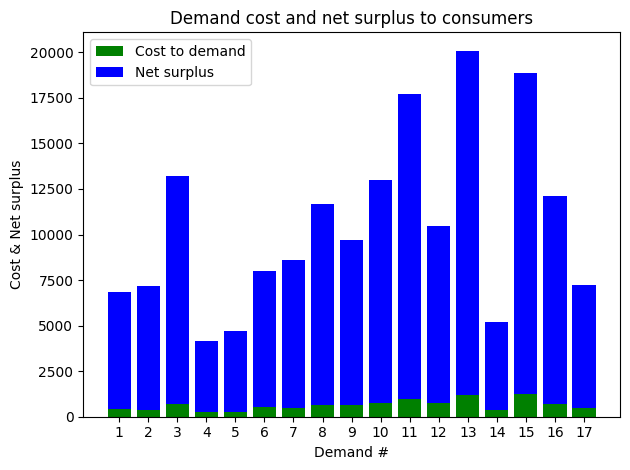

In [31]:
plt.bar(demand_results.index, demand_results["total_cost"], color="green", label = "Cost to demand")
plt.bar(demand_results.index, demand_results["net_surplus"], bottom = demand_results["total_cost"], color="blue", label = "Net surplus")
plt.xlabel("Demand #")
plt.ylabel("Cost & Net surplus")
plt.xticks(ticks = demand.index, labels = demand.index)
plt.title("Demand cost and net surplus to consumers")

plt.legend()
plt.tight_layout()
plt.savefig("results/demand_cost_and_net_surplus.png")
plt.show()

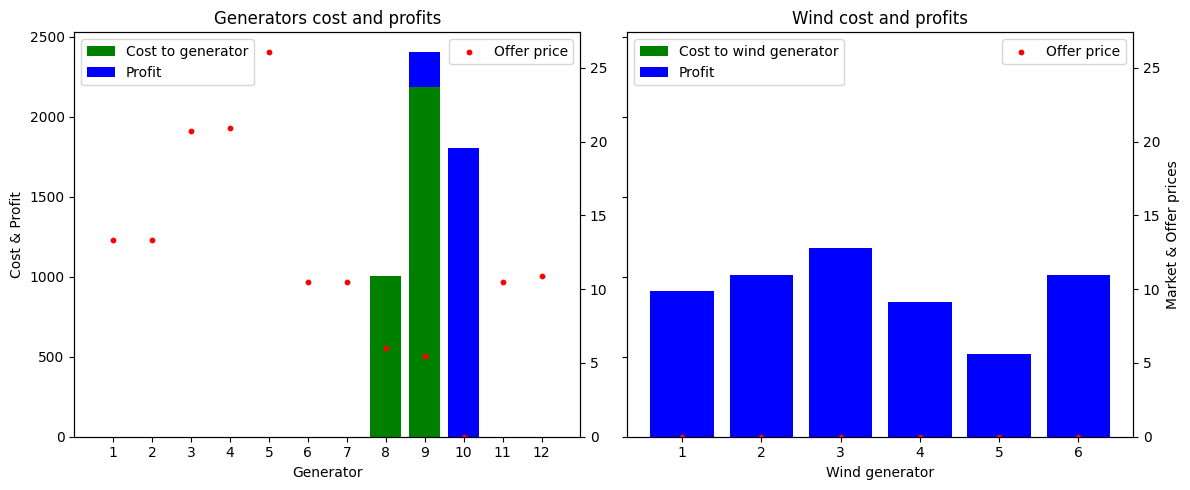

In [30]:
fig, ax = plt.subplots(ncols=2, figsize = (12,5), sharey=True)
ax[0].bar(generators_results.index, (generators_results["Pgen"]*generators_results["offer_price"]), color="green", label="Cost to generator")
ax[0].bar(generators_results.index, generators_results["profit"], bottom = (generators_results["Pgen"]*generators_results["offer_price"]), color="blue", label="Profit")
ax[0].set_xlabel("Generator")
ax[0].set_xticks(ticks = generators_results.index, labels=generators_results.index)
ax[0].set_ylabel("Cost & Profit")
ax[0].set_title("Generators cost and profits")

ax3 = ax[0].twinx()
#ax3.scatter(generators_results.index, [market_price for i in generators_results.index], color="red", label = "Market price")
ax3.scatter(generators_results.index, generators_results["offer_price"], color="red", label = "Offer price", s=10)
ax3.set_ylim(bottom = 0)

ax[0].legend()
ax3.legend()

ax[1].bar(wind_results.index, (wind_results["Pwin"]*wind_results["offer_price"]), color="green", label="Cost to wind generator")
ax[1].bar(wind_results.index, wind_results["profit"], bottom = (wind_results["Pwin"]*wind_results["offer_price"]), color="blue", label="Profit")
ax[1].set_xlabel("Wind generator")
ax[1].set_xticks(ticks = wind_results.index, labels=wind_results.index)
ax[1].set_title("Wind cost and profits")

ax4 = ax[1].twinx()
#ax4.scatter(wind_results.index, [market_price for i in wind_results.index], color="red", label = "Market price")
ax4.scatter(wind_results.index, wind_results["offer_price"], color="red", label = "Offer price", s=10)
ax4.set_ylim(ax3.get_ylim())
ax4.set_ylabel("Market & Offer prices")

ax[1].legend(loc="upper left")
ax4.legend()

plt.tight_layout()
plt.savefig("results/generator_costs_and_profits.png")
plt.show()

# Merit Order Curve

In [25]:
generators_plot = generators.loc[:, ["max_power_out", "offer_price"]]
wind_plot = wind_results.loc[:, ["Pwin", "offer_price"]]
wind_plot.rename(columns={"Pwin": "max_power_out"}, inplace=True)

generators_plot = pd.concat([generators_plot, wind_plot], axis = 0)
generators_plot.reset_index(drop=True, inplace=True)
generators_plot.index = generators_plot.index+1
generators_plot = generators_plot.sort_values(by="offer_price", ascending = True)
generators_plot["cumulative_generation"] = generators_plot["max_power_out"].cumsum()
generators_plot

,max_power_out,offer_price,cumulative_generation
13,151.114723,0.00,151.114723
14,167.994090,0.00,319.108813
15,195.898541,0.00,515.007354
16,140.072049,0.00,655.079403
10,300.000000,0.00,955.079403
17,85.845682,0.00,1040.925085
18,167.994090,0.00,1208.919175
9,400.000000,5.47,1608.919175
8,400.000000,6.02,2008.919175
7,155.000000,10.52,2163.919175


In [26]:
demand_plot = demand_results.loc[:, ["Pdem", "bid_price"]]
demand_plot = demand_plot.sort_values(by="bid_price", ascending=False)
demand_plot["cumulative_demand"] = demand_plot["Pdem"].cumsum()
demand_plot

,Pdem,bid_price,cumulative_demand
2,60.378390,118.426237,60.378390
3,111.877605,118.062623,172.255995
7,78.136740,109.846102,250.392735
8,106.550100,109.690298,356.942835
10,120.756780,107.601800,477.699615
11,165.152655,107.204517,642.852270
16,113.653440,106.376571,756.505710
5,44.395875,105.377104,800.901585
13,197.117685,101.943047,998.019270
1,67.481730,101.127217,1065.501000


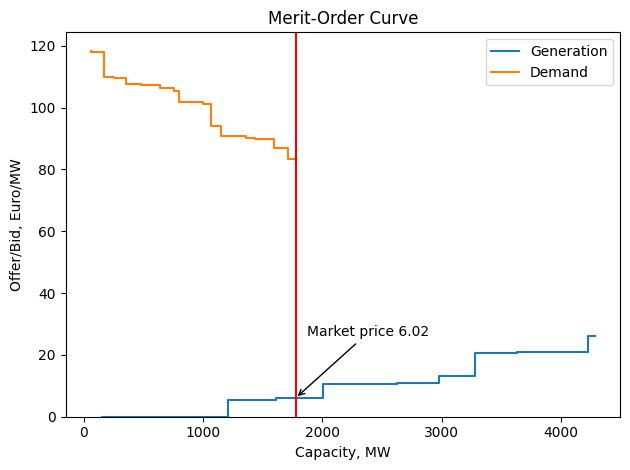

In [27]:
# Plot Merit-Order Curve
plt.step(generators_plot["cumulative_generation"], generators_plot["offer_price"], label = "Generation", where = "pre")
plt.step(demand_plot["cumulative_demand"], demand_plot["bid_price"], label = "Demand", where = "pre")
plt.axvline(x=demand_plot["cumulative_demand"].max(), color="red")
plt.ylabel("Offer/Bid, Euro/MW")
plt.xlabel("Capacity, MW")
plt.title("Merit-Order Curve")
plt.ylim(bottom=0, top=None)
plt.annotate(
    f"Market price {market_price}", 
    xy=(demand_plot["cumulative_demand"].max(),market_price), 
    xytext=(demand_plot["cumulative_demand"].max()+100,market_price + 20),
    arrowprops=dict(arrowstyle="->")
)

plt.legend()
plt.tight_layout()
plt.savefig("results/single_hour_merit_order.png")
plt.show()

In [28]:
# Market Clearing Price
market_price = model.dual[model.Pbalance]
print(f"The market price for this scenario is {market_price:,.2f} Euros")

The market price for this scenario is 6.02 Euros


In [29]:
# Total Welfare
welfare = pyo.value(model.objective)
print(f'The social welfare for this scenario is {welfare:,.2f} Euros')

The social welfare for this scenario is 175,455.22 Euros
